In [38]:
# =============================================================================
# CONFIGURACIÓN INICIAL Y IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os

# Configuración de warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para visualizaciones
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Librerías importadas y configuradas correctamente")
print(f"📅 Ejecución iniciada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Librerías importadas y configuradas correctamente
📅 Ejecución iniciada: 2025-10-15 08:43:41


In [39]:
# =============================================================================
# PARÁMETROS Y CONSTANTES DEL PROYECTO
# =============================================================================

# Ruta del archivo de datos
RUTA_ARCHIVO = r"E:\SPRINT 4\Competencias 2019-2023_Nueva.xlsx"
RUTA_SALIDA = r"E:\SPRINT 4"

# Años a analizar
AÑOS_ANALISIS = [2019, 2021, 2022, 2023]

# Competencias críticas específicas para Rapid Express (basado en onboarding)
COMPETENCIAS_CRITICAS = [
    'De trabajo en equipo',
    'De atención al público/ trato a clientes', 
    'De resolución de problemas (localización de problemas o fallos, análisis de sus causas y búsqueda de soluciones)',
    'Competencias técnicas específicas del puesto de trabajo',
    'Generales de tecnologías de la información'
]

# Umbrales para priorización
UMBRAL_ALTA_PRIORIDAD = 0.75  # Percentil 75
UMBRAL_MEDIA_PRIORIDAD = 0.5  # Percentil 50

print("📋 Parámetros del proyecto:")
print(f"   • Ruta archivo: {RUTA_ARCHIVO}")
print(f"   • Años análisis: {AÑOS_ANALISIS}")
print(f"   • Competencias críticas: {len(COMPETENCIAS_CRITICAS)}")

📋 Parámetros del proyecto:
   • Ruta archivo: E:\SPRINT 4\Competencias 2019-2023_Nueva.xlsx
   • Años análisis: [2019, 2021, 2022, 2023]
   • Competencias críticas: 5


In [40]:
# =============================================================================
# VALIDACIÓN INICIAL DEL ARCHIVO
# =============================================================================

def validar_archivo(ruta_archivo):
    """
    Valida la existencia y accesibilidad del archivo Excel
    """
    print("\n🔍 Validando archivo de datos...")
    
    if not os.path.exists(ruta_archivo):
        raise FileNotFoundError(f"❌ No se encuentra el archivo: {ruta_archivo}")
    
    if not ruta_archivo.endswith(('.xlsx', '.xls')):
        raise ValueError("❌ El archivo debe ser un Excel (.xlsx o .xls)")
    
    # Verificar que se puede leer
    try:
        archivo = pd.ExcelFile(ruta_archivo)
        hojas_disponibles = archivo.sheet_names
        print(f"✅ Archivo validado correctamente")
        print(f"   • Hojas disponibles: {hojas_disponibles}")
        return True
    except Exception as e:
        raise Exception(f"❌ Error al leer el archivo: {e}")

# Ejecutar validación
try:
    validar_archivo(RUTA_ARCHIVO)
    print("🎯 Archivo listo para procesamiento")
except Exception as e:
    print(e)
    exit()


🔍 Validando archivo de datos...
✅ Archivo validado correctamente
   • Hojas disponibles: ['2019', '2021', '2022', '2023']
🎯 Archivo listo para procesamiento


In [41]:
# =============================================================================
# LECTURA Y CARGA DE DATOS
# =============================================================================

def cargar_datos_excel(ruta_archivo, años):
    """
    Carga las hojas de Excel en un diccionario de DataFrames
    """
    print("\n📥 Cargando datos desde Excel...")
    
    datos = {}
    for año in años:
        try:
            df = pd.read_excel(ruta_archivo, sheet_name=str(año))
            datos[año] = df
            print(f"   ✅ Año {año}: {df.shape[0]} filas, {df.shape[1]} columnas")
        except Exception as e:
            print(f"   ❌ Error cargando año {año}: {e}")
    
    return datos

# Cargar datos
datos_brutos = cargar_datos_excel(RUTA_ARCHIVO, AÑOS_ANALISIS)

# Verificar estructura de cada año
print("\n📊 Estructura de datos por año:")
for año, df in datos_brutos.items():
    print(f"   • {año}: Columnas -> {list(df.columns)}")
    print(f"     Muestra competencias: {list(df.iloc[1:3, 0]) if len(df) > 1 else 'Datos insuficientes'}")


📥 Cargando datos desde Excel...
   ✅ Año 2019: 10 filas, 6 columnas
   ✅ Año 2021: 10 filas, 6 columnas
   ✅ Año 2022: 10 filas, 6 columnas
   ✅ Año 2023: 10 filas, 6 columnas

📊 Estructura de datos por año:
   • 2019: Columnas -> ['Unnamed: 0', 'TOTAL', 'NADA', 'POCO', 'BASTANTE', 'MUCHO']
     Muestra competencias: ['De trabajo en equipo', 'De atención al público/ trato a clientes']
   • 2021: Columnas -> ['Unnamed: 0', 'TOTAL', 'NADA', 'POCO', 'BASTANTE', 'MUCHO']
     Muestra competencias: ['De trabajo en equipo', 'De atención al público/ trato a clientes']
   • 2022: Columnas -> ['Unnamed: 0', 'TOTAL', 'NADA', 'POCO', 'BASTANTE', 'MUCHO']
     Muestra competencias: ['De trabajo en equipo', 'De atención al público/ trato a clientes']
   • 2023: Columnas -> ['Unnamed: 0', 'TOTAL', 'NADA', 'POCO', 'BASTANTE', 'MUCHO']
     Muestra competencias: ['De trabajo en equipo', 'De atención al público/ trato a clientes']


In [42]:
# =============================================================================
# FUNCIÓN DE LIMPIEZA Y TRANSFORMACIÓN DE DATOS
# =============================================================================

def limpiar_y_transformar_datos(df, año):
    """
    Realiza limpieza, estandarización y transformación de datos
    """
    # Crear copia para no modificar el original
    df_clean = df.copy()
    
    # 1. Estandarizar nombres de columnas
    df_clean.columns = ['Competencia', 'Total', 'Nada', 'Poco', 'Bastante', 'Mucho']
    
    # 2. Eliminar fila de encabezados si existe en los datos
    df_clean = df_clean.iloc[1:].reset_index(drop=True)
    
    # 3. Limpieza de textos
    df_clean['Competencia'] = df_clean['Competencia'].str.strip()
    
    # 4. Estandarización de nombres de competencias
    mapeo_competencias = {
        'Administrativas en oficina': 'Administrativas de oficina',
        'Administrativas de oficina': 'Administrativas de oficina',
        'Técnicas específicas del puesto de trabajo': 'Competencias técnicas específicas del puesto de trabajo',
        'Competencias técnicas, prácticas y otras específicas del puesto de trabajo': 'Competencias técnicas específicas del puesto de trabajo'
    }
    df_clean['Competencia'] = df_clean['Competencia'].replace(mapeo_competencias)
    
    # 5. Conversión a tipos numéricos
    columnas_numericas = ['Total', 'Nada', 'Poco', 'Bastante', 'Mucho']
    for col in columnas_numericas:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # 6. Crear métrica de Importancia Alta (Bastante + Mucho)
    df_clean['Importancia_Alta'] = df_clean['Bastante'] + df_clean['Mucho']
    
    # 7. Añadir metadatos
    df_clean['Año'] = año
    df_clean['Timestamp_Procesamiento'] = datetime.now()
    
    return df_clean

print("✅ Función de limpieza definida correctamente")

✅ Función de limpieza definida correctamente


In [43]:
# =============================================================================
# PROCESAMIENTO DE DATOS - APLICAR LIMPIEZA
# =============================================================================

print("\n🔧 Procesando y limpiando datos...")

datos_limpios = {}
for año, df in datos_brutos.items():
    try:
        datos_limpios[año] = limpiar_y_transformar_datos(df, año)
        print(f"   ✅ Año {año} procesado: {len(datos_limpios[año])} competencias")
    except Exception as e:
        print(f"   ❌ Error procesando año {año}: {e}")

# Consolidar todos los datos en un DataFrame único
df_completo = pd.concat(datos_limpios.values(), ignore_index=True)

print(f"\n📈 Datos consolidados:")
print(f"   • Total registros: {len(df_completo)}")
print(f"   • Años: {df_completo['Año'].unique()}")
print(f"   • Competencias únicas: {len(df_completo['Competencia'].unique())}")


🔧 Procesando y limpiando datos...
   ✅ Año 2019 procesado: 9 competencias
   ✅ Año 2021 procesado: 9 competencias
   ✅ Año 2022 procesado: 9 competencias
   ✅ Año 2023 procesado: 9 competencias

📈 Datos consolidados:
   • Total registros: 36
   • Años: [2019 2021 2022 2023]
   • Competencias únicas: 9


In [44]:
# =============================================================================
# VALIDACIÓN DE CALIDAD DE DATOS
# =============================================================================

def validar_calidad_datos(df):
    """
    Realiza validaciones exhaustivas de calidad de datos
    """
    print("\n🔎 Validando calidad de datos...")
    
    resultados_validacion = {}
    
    # 1. Verificar integridad de totales
    df['Suma_Columnas'] = df['Nada'] + df['Poco'] + df['Bastante'] + df['Mucho']
    errores_totales = df[abs(df['Suma_Columnas'] - 100) > 1]
    resultados_validacion['errores_totales'] = len(errores_totales)
    
    # 2. Verificar valores nulos
    valores_nulos = df.isnull().sum()
    resultados_validacion['valores_nulos'] = valores_nulos.sum()
    
    # 3. Verificar consistencia de competencias por año
    competencias_por_año = df.groupby('Año')['Competencia'].nunique()
    resultados_validacion['competencias_por_año'] = competencias_por_año
    
    # 4. Verificar rangos numéricos
    columnas_porcentaje = ['Nada', 'Poco', 'Bastante', 'Mucho', 'Importancia_Alta']
    rangos_correctos = all(df[col].between(0, 100).all() for col in columnas_porcentaje)
    resultados_validacion['rangos_correctos'] = rangos_correctos
    
    # Mostrar resultados
    print(f"   • Registros con problemas en totales: {resultados_validacion['errores_totales']}")
    print(f"   • Valores nulos totales: {resultados_validacion['valores_nulos']}")
    print(f"   • Competencias por año:")
    for año, count in resultados_validacion['competencias_por_año'].items():
        print(f"       {año}: {count} competencias")
    print(f"   • Rangos numéricos correctos: {'✅' if resultados_validacion['rangos_correctos'] else '❌'}")
    
    return resultados_validacion

# Ejecutar validación
resultados_validacion = validar_calidad_datos(df_completo)


🔎 Validando calidad de datos...
   • Registros con problemas en totales: 0
   • Valores nulos totales: 0
   • Competencias por año:
       2019: 9 competencias
       2021: 9 competencias
       2022: 9 competencias
       2023: 9 competencias
   • Rangos numéricos correctos: ✅


In [45]:
# =============================================================================
# ANÁLISIS DE TENDENCIAS TEMPORALES
# =============================================================================

def analizar_tendencias_temporales(df):
    """
    Analiza la evolución de las competencias a lo largo del tiempo
    """
    print("\n📈 Analizando tendencias temporales...")
    
    # Crear pivot table para análisis de tendencias
    pivot_tendencias = df.pivot_table(
        index='Competencia', 
        columns='Año', 
        values='Importancia_Alta',
        aggfunc='mean'
    ).reset_index()
    
    # Calcular métricas de crecimiento
    pivot_tendencias['Crecimiento_Absoluto_2019_2023'] = pivot_tendencias[2023] - pivot_tendencias[2019]
    pivot_tendencias['Crecimiento_Relativo_2019_2023'] = (
        (pivot_tendencias[2023] - pivot_tendencias[2019]) / pivot_tendencias[2019] * 100
    ).round(2)
    
    # Identificar tendencias
    pivot_tendencias['Tendencia'] = np.where(
        pivot_tendencias['Crecimiento_Absoluto_2019_2023'] > 5, 'CRECIENTE',
        np.where(pivot_tendencias['Crecimiento_Absoluto_2019_2023'] > 0, 'ESTABLE', 'DECRECIENTE')
    )
    
    return pivot_tendencias

# Ejecutar análisis de tendencias
tendencias = analizar_tendencias_temporales(df_completo)

print("\n🎯 COMPETENCIAS CON MAYOR CRECIMIENTO (2019-2023):")
top_crecimiento = tendencias.nlargest(5, 'Crecimiento_Absoluto_2019_2023')[['Competencia', 'Crecimiento_Absoluto_2019_2023', 'Crecimiento_Relativo_2019_2023', 'Tendencia']]
print(top_crecimiento.to_string(index=False))

print("\n📉 COMPETENCIAS CON MAYOR DECRECIMIENTO (2019-2023):")
top_decrecimiento = tendencias.nsmallest(3, 'Crecimiento_Absoluto_2019_2023')[['Competencia', 'Crecimiento_Absoluto_2019_2023', 'Crecimiento_Relativo_2019_2023', 'Tendencia']]
print(top_decrecimiento.to_string(index=False))


📈 Analizando tendencias temporales...

🎯 COMPETENCIAS CON MAYOR CRECIMIENTO (2019-2023):
                                                                                                     Competencia  Crecimiento_Absoluto_2019_2023  Crecimiento_Relativo_2019_2023 Tendencia
                                                         Competencias técnicas específicas del puesto de trabajo                           7.653                           16.57 CRECIENTE
                                                              Básicas de cálculo y/o comunicación oral o escrita                           7.034                           17.21 CRECIENTE
                                                                      Generales de tecnologías de la información                           5.995                           10.58 CRECIENTE
                                                                  Profesionales de tecnologías de la información                           5.264                  

In [46]:
# =============================================================================
# VERIFICACIÓN DE DATOS DE TENDENCIAS - CELDA NUEVA
# =============================================================================

print("\n🔍 VERIFICACIÓN DE DATOS DE TENDENCIAS:")
print("="*50)

# Verificar que tendencias tenga datos
print(f"• Filas en tendencias: {len(tendencias)}")
print(f"• Columnas en tendencias: {list(tendencias.columns)}")
print(f"• Competencias en tendencias: {len(tendencias['Competencia'].unique())}")

# Mostrar algunas tendencias para verificar
print(f"\n📈 Muestra de tendencias calculadas:")
muestra_tendencias = tendencias[['Competencia', 2019, 2023, 'Crecimiento_Absoluto_2019_2023']].head()
print(muestra_tendencias.to_string(index=False))

# Verificar merge potencial
print(f"\n🔗 Verificando compatibilidad para merge:")
df_ultimo_año = df_completo[df_completo['Año'] == max(df_completo['Año'])].copy()
competencias_comunes = set(df_ultimo_año['Competencia']).intersection(set(tendencias['Competencia']))
print(f"• Competencias en último año: {len(df_ultimo_año['Competencia'].unique())}")
print(f"• Competencias en tendencias: {len(tendencias['Competencia'].unique())}")
print(f"• Competencias comunes para merge: {len(competencias_comunes)}")

# Verificar que no haya valores NaN en crecimiento
print(f"\n📊 Calidad de datos de crecimiento:")
print(f"• Valores NaN en Crecimiento_Absoluto_2019_2023: {tendencias['Crecimiento_Absoluto_2019_2023'].isna().sum()}")
print(f"• Rango de crecimiento: {tendencias['Crecimiento_Absoluto_2019_2023'].min():.2f} a {tendencias['Crecimiento_Absoluto_2019_2023'].max():.2f}")


🔍 VERIFICACIÓN DE DATOS DE TENDENCIAS:
• Filas en tendencias: 9
• Columnas en tendencias: ['Competencia', 2019, 2021, 2022, 2023, 'Crecimiento_Absoluto_2019_2023', 'Crecimiento_Relativo_2019_2023', 'Tendencia']
• Competencias en tendencias: 9

📈 Muestra de tendencias calculadas:
                                                                                                     Competencia   2019   2023  Crecimiento_Absoluto_2019_2023
                                                                                      Administrativas de oficina 62.011 65.457                           3.446
                                                              Básicas de cálculo y/o comunicación oral o escrita 40.869 47.903                           7.034
                                                         Competencias técnicas específicas del puesto de trabajo 46.193 53.846                           7.653
                                                                        De atención


🎯 ANALISIS ESPECÍFICO PARA RAPID EXPRESS
   (Basado en competencias críticas para logística y transporte)

📋 ANÁLISIS DETALLADO POR COMPETENCIA CRÍTICA:

🏷️  De trabajo en equipo
   • Importancia 2019: 90.8%
   • Importancia 2023: 92.6%
   • Crecimiento: +1.7% (+1.9%)
   • 🟡 MANTENER
   • Justificación: Alta importancia + Sector crítico

🏷️  De atención al público/ trato a clientes
   • Importancia 2019: 87.3%
   • Importancia 2023: 87.3%
   • Crecimiento: +0.0% (+0.0%)
   • 🟡 MANTENER
   • Justificación: Alta importancia + Sector crítico

🏷️  De resolución de problemas (localización de problemas o fallos, análisis de sus causas y búsqueda de soluciones)
   • Importancia 2019: 79.2%
   • Importancia 2023: 83.3%
   • Crecimiento: +4.1% (+5.2%)
   • 🟡 MANTENER
   • Justificación: Alta importancia + Sector crítico

🏷️  Competencias técnicas específicas del puesto de trabajo
   • Importancia 2019: 46.2%
   • Importancia 2023: 53.8%
   • Crecimiento: +7.7% (+16.6%)
   • 🔴 ALTA PRIORIDAD
  

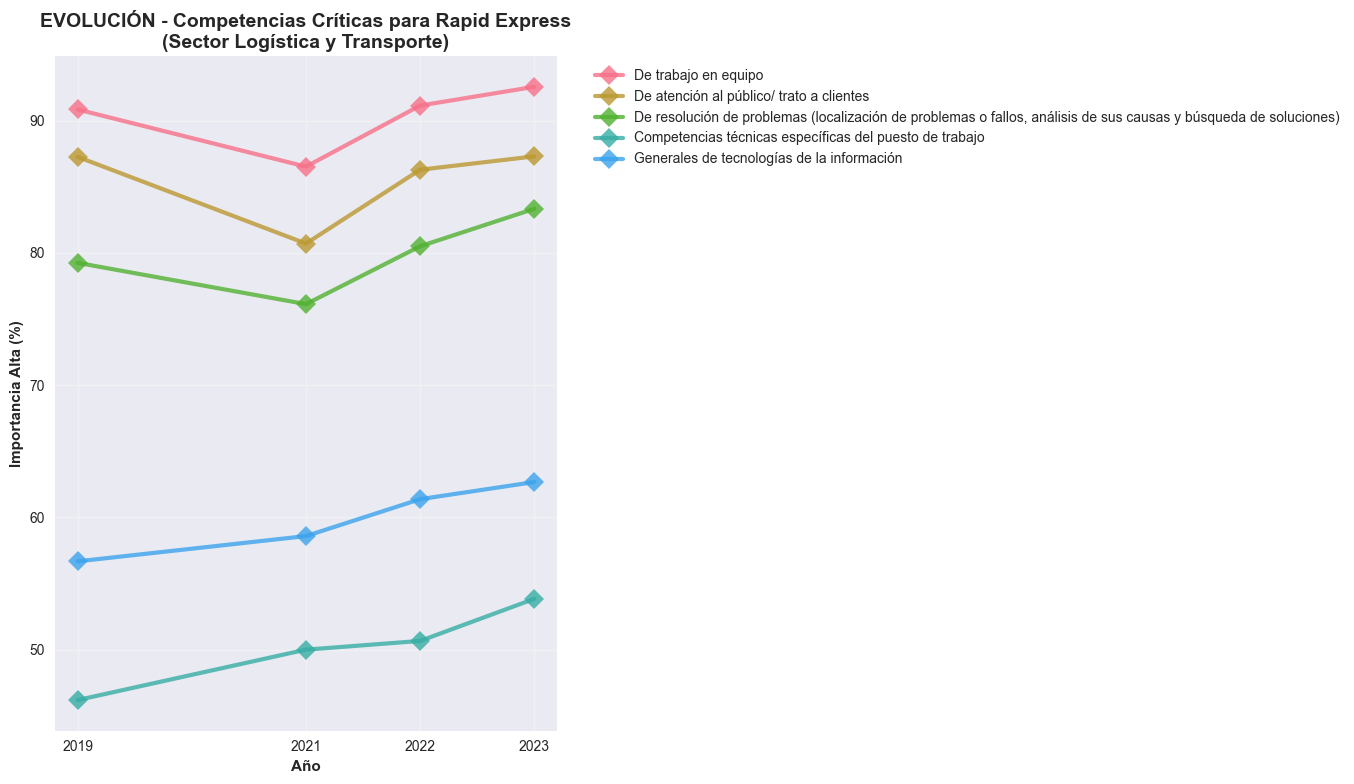

In [47]:
# =============================================================================
# ANÁLISIS ESPECÍFICO PARA RAPID EXPRESS
# =============================================================================

print("\n🎯 ANALISIS ESPECÍFICO PARA RAPID EXPRESS")
print("   (Basado en competencias críticas para logística y transporte)")

# Filtrar competencias críticas
df_criticas = df_completo[df_completo['Competencia'].isin(COMPETENCIAS_CRITICAS)].copy()

# Análisis detallado por competencia crítica
print("\n📋 ANÁLISIS DETALLADO POR COMPETENCIA CRÍTICA:")
print("="*80)

for competencia in COMPETENCIAS_CRITICAS:
    datos_competencia = df_criticas[df_criticas['Competencia'] == competencia]
    
    if len(datos_competencia) > 0:
        datos_2019 = datos_competencia[datos_competencia['Año'] == 2019]
        datos_2023 = datos_competencia[datos_competencia['Año'] == 2023]
        
        if len(datos_2019) > 0 and len(datos_2023) > 0:
            imp_2019 = datos_2019['Importancia_Alta'].values[0]
            imp_2023 = datos_2023['Importancia_Alta'].values[0]
            crecimiento = imp_2023 - imp_2019
            variacion_pct = (crecimiento / imp_2019 * 100) if imp_2019 > 0 else 0
            
            # Determinar prioridad
            if crecimiento > 5:
                prioridad = "🔴 ALTA PRIORIDAD"
                motivo = "Crecimiento significativo + Sector crítico"
            elif imp_2023 > 80:
                prioridad = "🟡 MANTENER"
                motivo = "Alta importancia + Sector crítico"
            else:
                prioridad = "🟢 EVALUAR"
                motivo = "Importancia media en sector crítico"
            
            print(f"\n🏷️  {competencia}")
            print(f"   • Importancia 2019: {imp_2019:.1f}%")
            print(f"   • Importancia 2023: {imp_2023:.1f}%")
            print(f"   • Crecimiento: {crecimiento:+.1f}% ({variacion_pct:+.1f}%)")
            print(f"   • {prioridad}")
            print(f"   • Justificación: {motivo}")

# Gráfico específico para competencias críticas
plt.figure(figsize=(14, 8))

for competencia in COMPETENCIAS_CRITICAS:
    datos_competencia = df_criticas[df_criticas['Competencia'] == competencia]
    if len(datos_competencia) > 0:
        plt.plot(datos_competencia['Año'], datos_competencia['Importancia_Alta'], 
                 marker='D', linewidth=3, markersize=10, label=competencia, alpha=0.8)

plt.title('EVOLUCIÓN - Competencias Críticas para Rapid Express\n(Sector Logística y Transporte)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Año', fontweight='bold')
plt.ylabel('Importancia Alta (%)', fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(AÑOS_ANALISIS)
plt.tight_layout()
plt.show()

In [48]:
# =============================================================================
# SISTEMA DE PRIORIZACIÓN ESTRATÉGICA - VERSIÓN CORREGIDA
# =============================================================================

def calcular_priorizacion_estrategica(df, tendencias, umbral_alto=0.75, umbral_medio=0.5):
    """
    Calcula prioridades estratégicas basadas en múltiples criterios - CORREGIDO
    """
    print("\n🎯 Calculando priorización estratégica...")
    
    # Obtener datos del año más reciente
    df_ultimo_año = df[df['Año'] == max(df['Año'])].copy()
    
    # CORRECCIÓN 1: Hacer merge explícito con tendencias ANTES de calcular scores
    df_ultimo_año = df_ultimo_año.merge(
        tendencias[['Competencia', 'Crecimiento_Absoluto_2019_2023']], 
        on='Competencia', 
        how='left'
    )
    
    # Calcular score compuesto (50% importancia actual, 30% crecimiento, 20% sector crítico)
    df_ultimo_año['Score_Importancia'] = df_ultimo_año['Importancia_Alta'] / 100
    
    # CORRECCIÓN 2: Score de crecimiento (normalizado) - manejar caso cuando max_crecimiento es 0
    max_crecimiento = abs(df_ultimo_año['Crecimiento_Absoluto_2019_2023']).max()
    if max_crecimiento == 0:
        max_crecimiento = 1  # Evitar división por cero
    
    df_ultimo_año['Score_Crecimiento'] = (
        df_ultimo_año['Crecimiento_Absoluto_2019_2023'] / max_crecimiento
    )
    
    # Score de relevancia sectorial (1.0 para críticas, 0.5 para otras)
    df_ultimo_año['Score_Sector'] = df_ultimo_año['Competencia'].apply(
        lambda x: 1.0 if x in COMPETENCIAS_CRITICAS else 0.5
    )
    
    # CORRECCIÓN 3: Manejar valores NaN antes del cálculo final
    df_ultimo_año['Score_Crecimiento'] = df_ultimo_año['Score_Crecimiento'].fillna(0)
    
    # Score final ponderado
    df_ultimo_año['Score_Final'] = (
        df_ultimo_año['Score_Importancia'] * 0.5 +
        df_ultimo_año['Score_Crecimiento'] * 0.3 +
        df_ultimo_año['Score_Sector'] * 0.2
    )
    
    # Clasificar por prioridad
    df_ultimo_año['Prioridad'] = pd.cut(
        df_ultimo_año['Score_Final'],
        bins=[0, umbral_medio, umbral_alto, 1],
        labels=['BAJA', 'MEDIA', 'ALTA'],
        include_lowest=True
    )
    
    return df_ultimo_año.sort_values('Score_Final', ascending=False)

# Calcular priorización
df_priorizacion = calcular_priorizacion_estrategica(df_completo, tendencias)

# Mostrar resultados de priorización
print("\n📊 RESULTADOS DE PRIORIZACIÓN ESTRATÉGICA:")
print("="*100)

for prioridad in ['ALTA', 'MEDIA', 'BAJA']:
    df_prioridad = df_priorizacion[df_priorizacion['Prioridad'] == prioridad]
    
    if prioridad == 'ALTA':
        print(f"\n🔴 COMPETENCIAS DE ALTA PRIORIDAD (Inversión estratégica):")
        print("   " + "="*50)
    elif prioridad == 'MEDIA':
        print(f"\n🟡 COMPETENCIAS DE MEDIA PRIORIDAD (Optimización):")
        print("   " + "="*50)
    else:
        print(f"\n🟢 COMPETENCIAS DE BAJA PRIORIDAD (Mantenimiento):")
        print("   " + "="*50)
    
    for _, row in df_prioridad.iterrows():
        es_critica = "⭐" if row['Competencia'] in COMPETENCIAS_CRITICAS else "  "
        print(f"   {es_critica} {row['Competencia']}")
        print(f"      • Score: {row['Score_Final']:.3f} | Importancia: {row['Importancia_Alta']:.1f}% | "
              f"Crecimiento: {row['Crecimiento_Absoluto_2019_2023']:+.1f}%")


🎯 Calculando priorización estratégica...

📊 RESULTADOS DE PRIORIZACIÓN ESTRATÉGICA:

🔴 COMPETENCIAS DE ALTA PRIORIDAD (Inversión estratégica):
   ⭐ De resolución de problemas (localización de problemas o fallos, análisis de sus causas y búsqueda de soluciones)
      • Score: 0.777 | Importancia: 83.3% | Crecimiento: +4.1%
   ⭐ Competencias técnicas específicas del puesto de trabajo
      • Score: 0.769 | Importancia: 53.8% | Crecimiento: +7.7%

🟡 COMPETENCIAS DE MEDIA PRIORIDAD (Optimización):
   ⭐ Generales de tecnologías de la información
      • Score: 0.748 | Importancia: 62.7% | Crecimiento: +6.0%
   ⭐ De trabajo en equipo
      • Score: 0.730 | Importancia: 92.6% | Crecimiento: +1.7%
   ⭐ De atención al público/ trato a clientes
      • Score: 0.638 | Importancia: 87.3% | Crecimiento: +0.0%
      Básicas de cálculo y/o comunicación oral o escrita
      • Score: 0.615 | Importancia: 47.9% | Crecimiento: +7.0%
      Administrativas de oficina
      • Score: 0.562 | Importancia: 65

In [49]:
# =============================================================================
# PREPROCESAMIENTO Y VALIDACIÓN DE DATOS PARA VISUALIZACIONES - CORREGIDO
# =============================================================================

print("🔧 Preprocesando datos para visualizaciones...")

# Asegurar que df_priorizacion esté limpio
df_priorizacion_clean = df_priorizacion.copy()

# 1. Limpiar columna Prioridad
df_priorizacion_clean['Prioridad'] = df_priorizacion_clean['Prioridad'].fillna('BAJA')

# 2. Asegurar que las columnas numéricas estén limpias
df_priorizacion_clean['Importancia_Alta'] = pd.to_numeric(df_priorizacion_clean['Importancia_Alta'], errors='coerce').fillna(0)
df_priorizacion_clean['Score_Final'] = pd.to_numeric(df_priorizacion_clean['Score_Final'], errors='coerce').fillna(0)
df_priorizacion_clean['Crecimiento_Absoluto_2019_2023'] = pd.to_numeric(df_priorizacion_clean['Crecimiento_Absoluto_2019_2023'], errors='coerce').fillna(0)

# CORRECCIÓN: Ya no necesitamos merge adicional porque se hizo dentro de la función
df_matriz_clean = df_priorizacion_clean.copy()
df_matriz_clean['Crecimiento'] = df_matriz_clean['Crecimiento_Absoluto_2019_2023']

print("✅ Datos preprocesados correctamente")
print(f"   • Prioridades: {df_priorizacion_clean['Prioridad'].value_counts().to_dict()}")
print(f"   • Rango Importancia: {df_priorizacion_clean['Importancia_Alta'].min():.1f}% - {df_priorizacion_clean['Importancia_Alta'].max():.1f}%")
print(f"   • Rango Score Final: {df_priorizacion_clean['Score_Final'].min():.3f} - {df_priorizacion_clean['Score_Final'].max():.3f}")

🔧 Preprocesando datos para visualizaciones...
✅ Datos preprocesados correctamente
   • Prioridades: {'MEDIA': 5, 'BAJA': 2, 'ALTA': 2}
   • Rango Importancia: 38.4% - 92.6%
   • Rango Score Final: 0.460 - 0.777



📊 Generando Mapa de Calor de Prioridades...


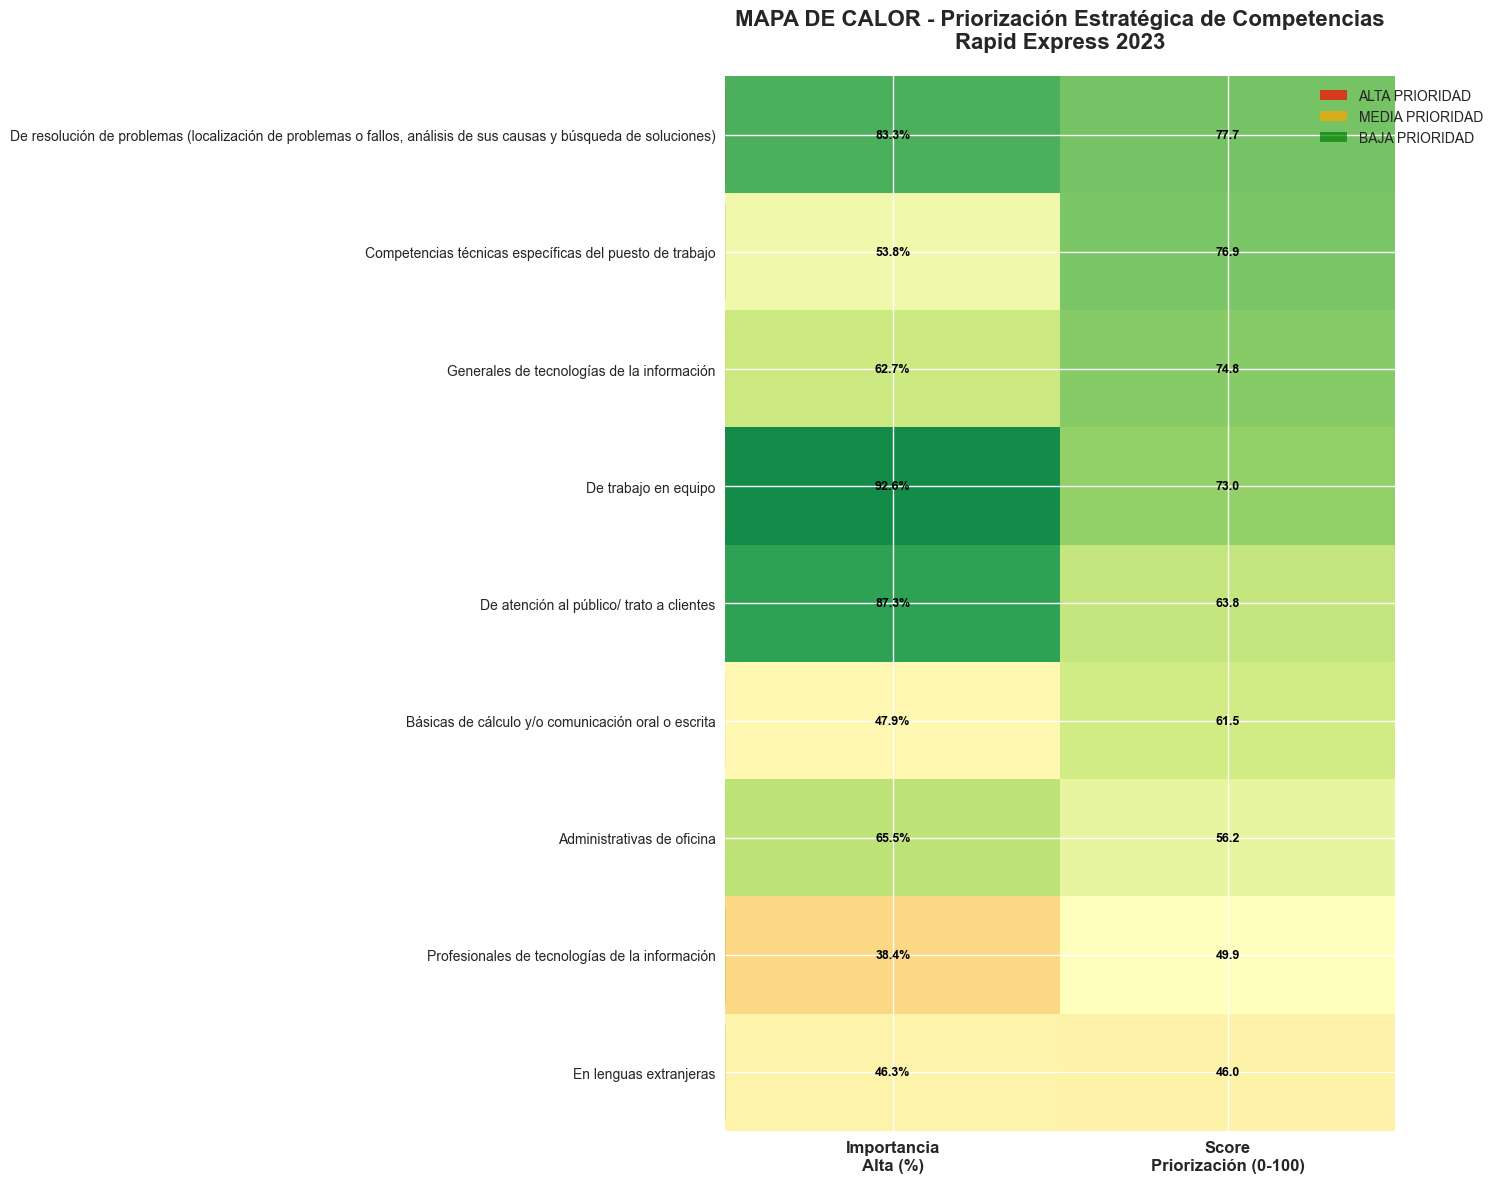

✅ Mapa de calor estratégico generado correctamente


In [50]:
# =============================================================================
# VISUALIZACIÓN 1 - MAPA DE CALOR DE PRIORIDADES ESTRATÉGICAS
# =============================================================================

print("\n📊 Generando Mapa de Calor de Prioridades...")

# Usar datos limpios
df_heatmap_estrategico = df_priorizacion_clean[['Competencia', 'Importancia_Alta', 'Score_Final', 'Prioridad']].copy()
df_heatmap_estrategico = df_heatmap_estrategico.sort_values('Score_Final', ascending=False)

# Crear matriz para heatmap
heatmap_data = df_heatmap_estrategico[['Importancia_Alta', 'Score_Final']].values
competencies = df_heatmap_estrategico['Competencia'].tolist()

# Configurar el heatmap
fig, ax = plt.subplots(figsize=(16, 12))

# Normalizar Score_Final para el heatmap (convertir a escala 0-100 para visualización)
heatmap_data[:, 1] = heatmap_data[:, 1] * 100  # Convertir score a porcentaje

# Crear heatmap
im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

# Personalizar ejes
ax.set_xticks([0, 1])
ax.set_xticklabels(['Importancia\nAlta (%)', 'Score\nPriorización (0-100)'], fontsize=12, fontweight='bold')
ax.set_yticks(range(len(competencies)))
ax.set_yticklabels(competencies, fontsize=10)

# Añadir valores en las celdas
for i in range(len(competencies)):
    for j in range(2):
        if j == 0:  # Importancia Alta
            valor = heatmap_data[i, j]
            texto = f'{valor:.1f}%'
        else:  # Score (ya convertido a 0-100)
            valor = heatmap_data[i, j]
            texto = f'{valor:.1f}'
        
        ax.text(j, i, texto, ha="center", va="center", color="black", fontweight='bold', fontsize=9)

# Añadir barras de color para prioridad
colors_priority = {'ALTA': 'red', 'MEDIA': 'orange', 'BAJA': 'green'}
for i, priority in enumerate(df_heatmap_estrategico['Prioridad']):
    color = colors_priority.get(priority, 'gray')
    ax.add_patch(plt.Rectangle((-0.8, i-0.4), 0.3, 0.8, color=color, alpha=0.7))

# Añadir leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='ALTA PRIORIDAD'),
    Patch(facecolor='orange', alpha=0.7, label='MEDIA PRIORIDAD'),
    Patch(facecolor='green', alpha=0.7, label='BAJA PRIORIDAD')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))

ax.set_title('MAPA DE CALOR - Priorización Estratégica de Competencias\nRapid Express 2023', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("✅ Mapa de calor estratégico generado correctamente")


📈 Generando Matriz de Priorización...


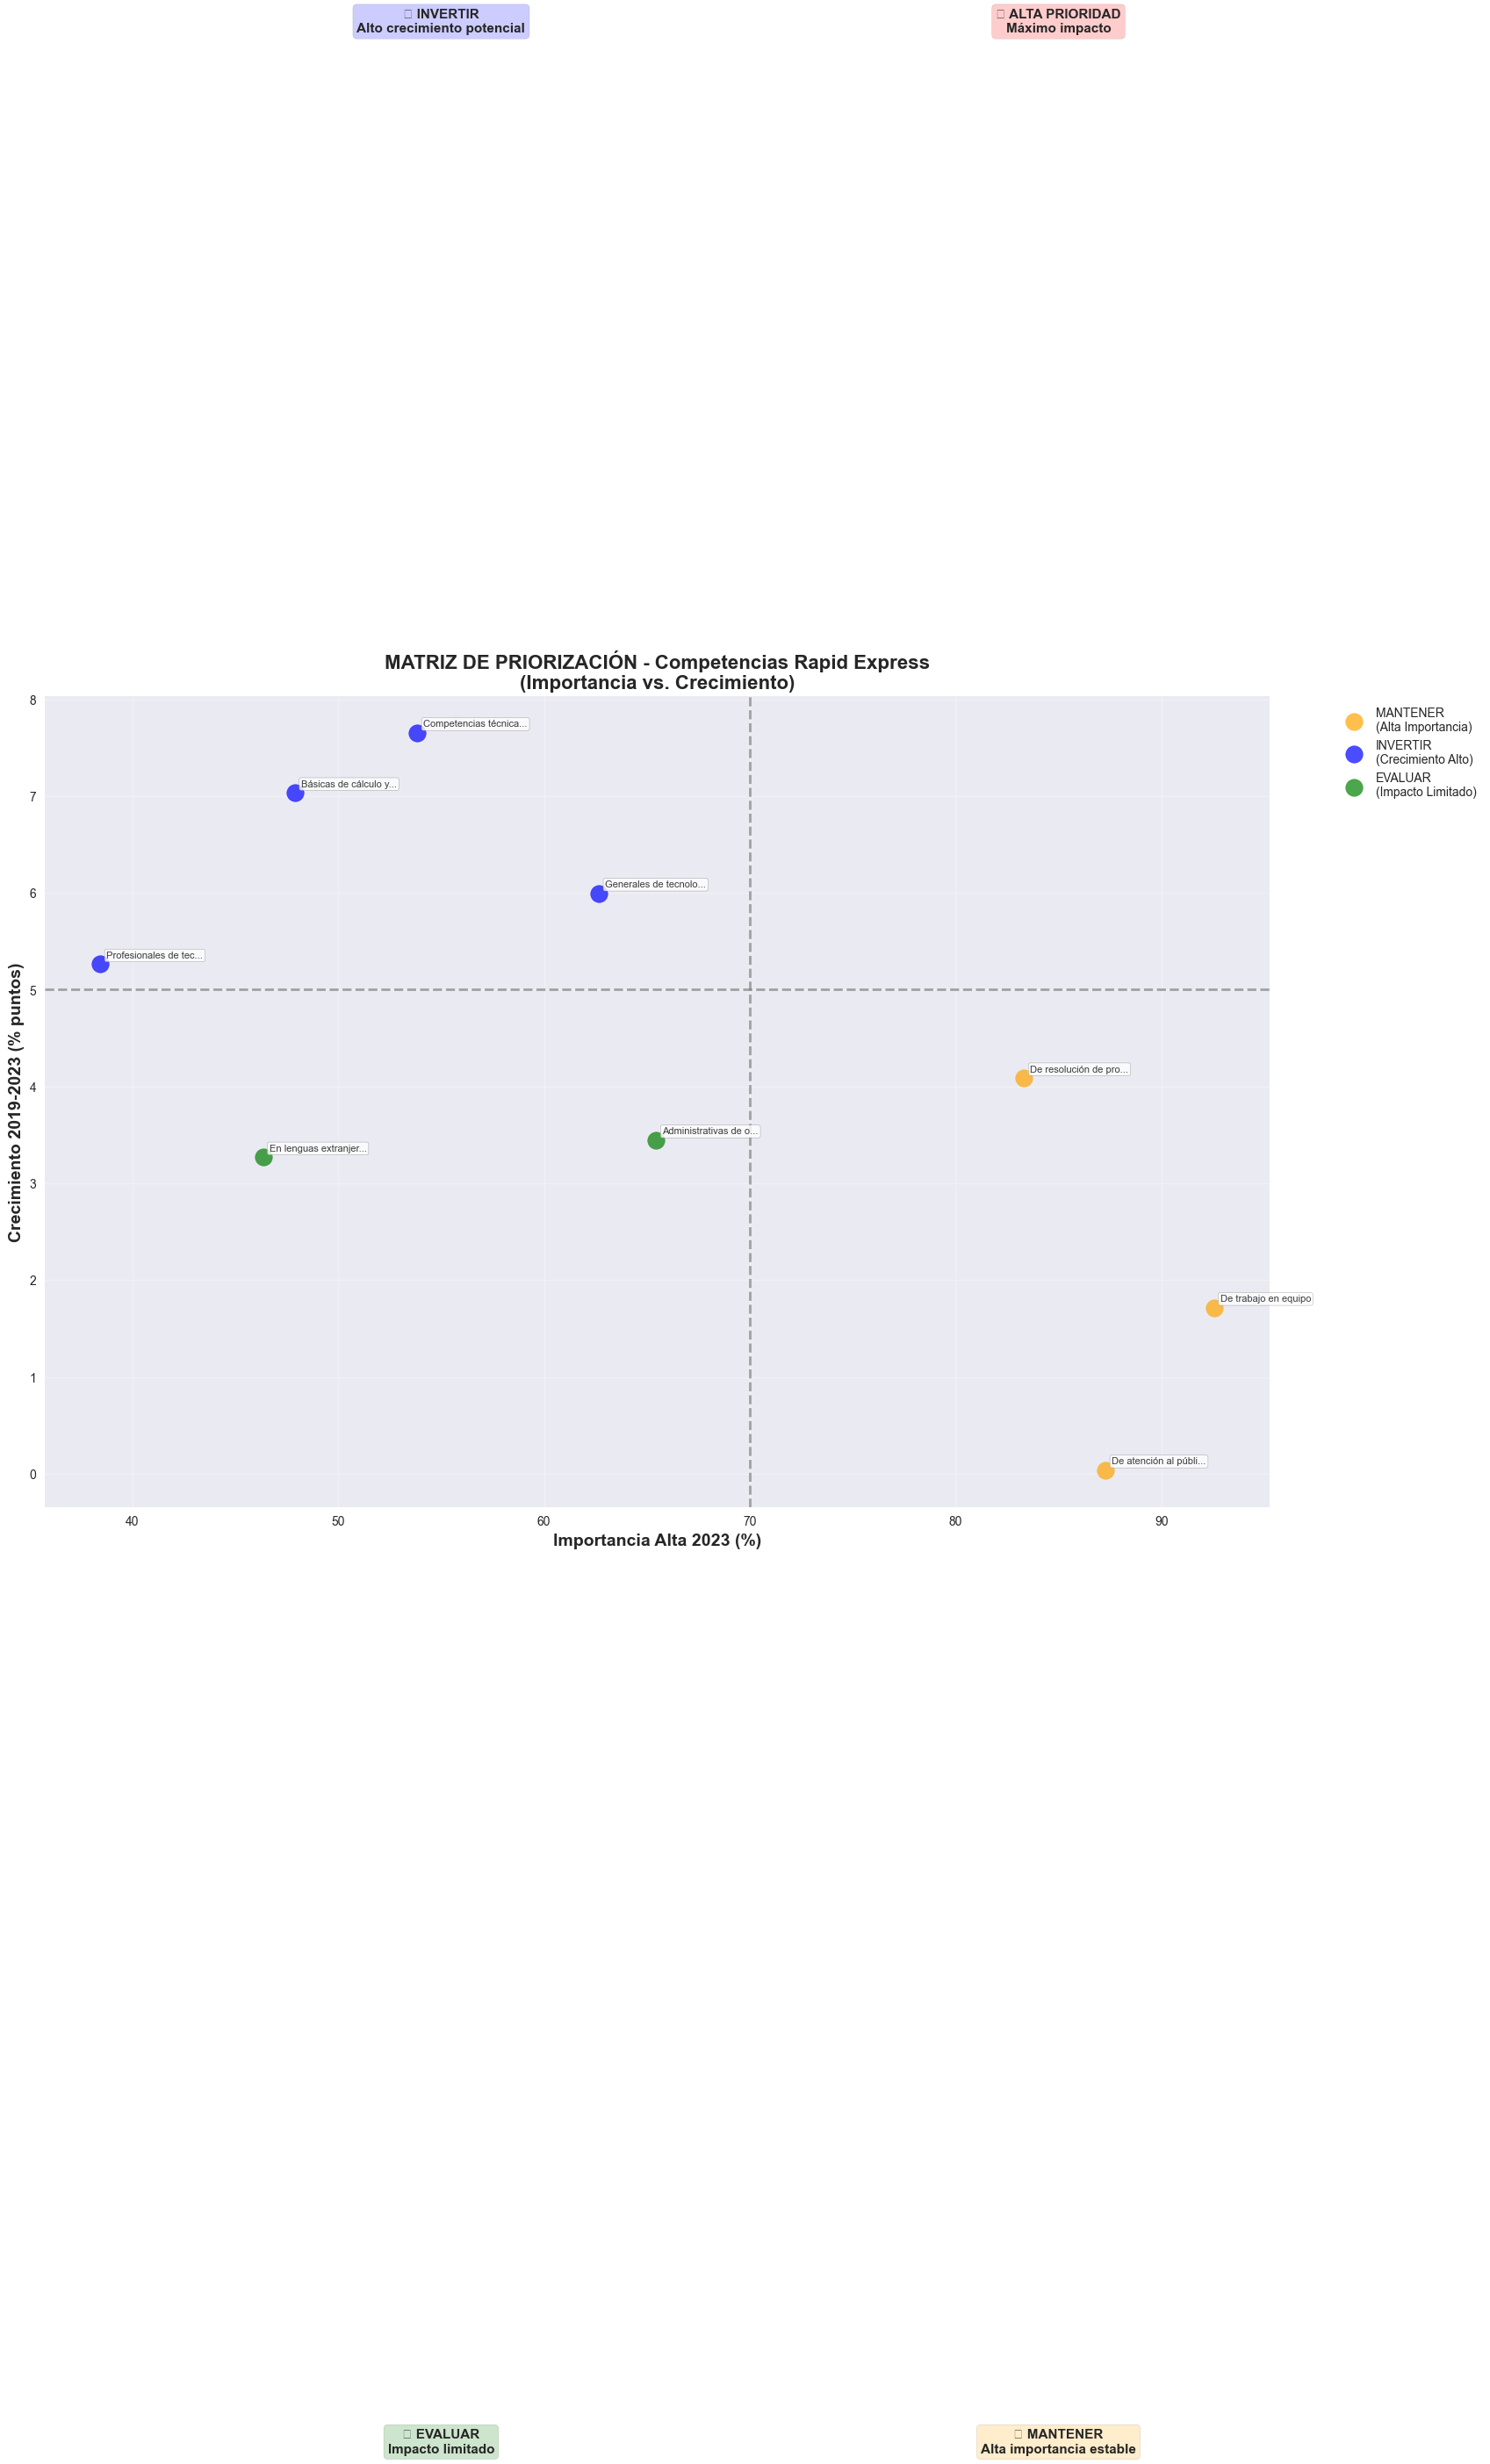

✅ Matriz de priorización generada correctamente


In [51]:
# =============================================================================
# VISUALIZACIÓN 2 - MATRIZ DE PRIORIZACIÓN (IMPORTANCIA vs CRECIMIENTO)
# =============================================================================

print("\n📈 Generando Matriz de Priorización...")

# Usar datos limpios de la matriz
df_matriz = df_matriz_clean.copy()

# Definir umbrales
umbral_importancia = 70
umbral_crecimiento = 5

# Crear categorías
def clasificar_cuadrante(importancia, crecimiento):
    if importancia >= umbral_importancia and crecimiento >= umbral_crecimiento:
        return 'ALTA PRIORIDAD\n(Máximo Impacto)'
    elif importancia >= umbral_importancia and crecimiento < umbral_crecimiento:
        return 'MANTENER\n(Alta Importancia)'
    elif importancia < umbral_importancia and crecimiento >= umbral_crecimiento:
        return 'INVERTIR\n(Crecimiento Alto)'
    else:
        return 'EVALUAR\n(Impacto Limitado)'

df_matriz['Cuadrante'] = df_matriz.apply(
    lambda x: clasificar_cuadrante(x['Importancia_Alta'], x['Crecimiento']), axis=1
)

# Configurar el scatter plot
plt.figure(figsize=(18, 12))

# Colores por cuadrante
colores_cuadrantes = {
    'ALTA PRIORIDAD\n(Máximo Impacto)': 'red',
    'MANTENER\n(Alta Importancia)': 'orange', 
    'INVERTIR\n(Crecimiento Alto)': 'blue',
    'EVALUAR\n(Impacto Limitado)': 'green'
}

# Crear scatter plot
for cuadrante, color in colores_cuadrantes.items():
    datos_cuadrante = df_matriz[df_matriz['Cuadrante'] == cuadrante]
    if len(datos_cuadrante) > 0:
        plt.scatter(datos_cuadrante['Importancia_Alta'], datos_cuadrante['Crecimiento'],
                   c=color, s=200, alpha=0.7, label=cuadrante)

# Añadir etiquetas para cada punto
for _, row in df_matriz.iterrows():
    nombre_corto = row['Competencia'][:20] + '...' if len(row['Competencia']) > 20 else row['Competencia']
    
    plt.annotate(nombre_corto, 
                (row['Importancia_Alta'], row['Crecimiento']),
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=8, 
                alpha=0.9,
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='gray'))

# Añadir líneas de referencia
plt.axvline(x=umbral_importancia, color='gray', linestyle='--', alpha=0.7, linewidth=2)
plt.axhline(y=umbral_crecimiento, color='gray', linestyle='--', alpha=0.7, linewidth=2)

# Configurar ejes y título
plt.xlabel('Importancia Alta 2023 (%)', fontsize=14, fontweight='bold')
plt.ylabel('Crecimiento 2019-2023 (% puntos)', fontsize=14, fontweight='bold')
plt.title('MATRIZ DE PRIORIZACIÓN - Competencias Rapid Express\n(Importancia vs. Crecimiento)', 
          fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Añadir anotaciones explicativas
plt.text(85, 15, '🔴 ALTA PRIORIDAD\nMáximo impacto', 
         fontsize=11, fontweight='bold', 
         bbox=dict(boxstyle="round", facecolor='red', alpha=0.2),
         ha='center', va='center')

plt.text(85, -10, '🟡 MANTENER\nAlta importancia estable', 
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle="round", facecolor='orange', alpha=0.2),
         ha='center', va='center')

plt.text(55, 15, '🔵 INVERTIR\nAlto crecimiento potencial', 
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle="round", facecolor='blue', alpha=0.2),
         ha='center', va='center')

plt.text(55, -10, '🟢 EVALUAR\nImpacto limitado', 
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle="round", facecolor='green', alpha=0.2),
         ha='center', va='center')

plt.tight_layout()
plt.show()

print("✅ Matriz de priorización generada correctamente")


🎯 Generando Radar Chart de Competencias Críticas...


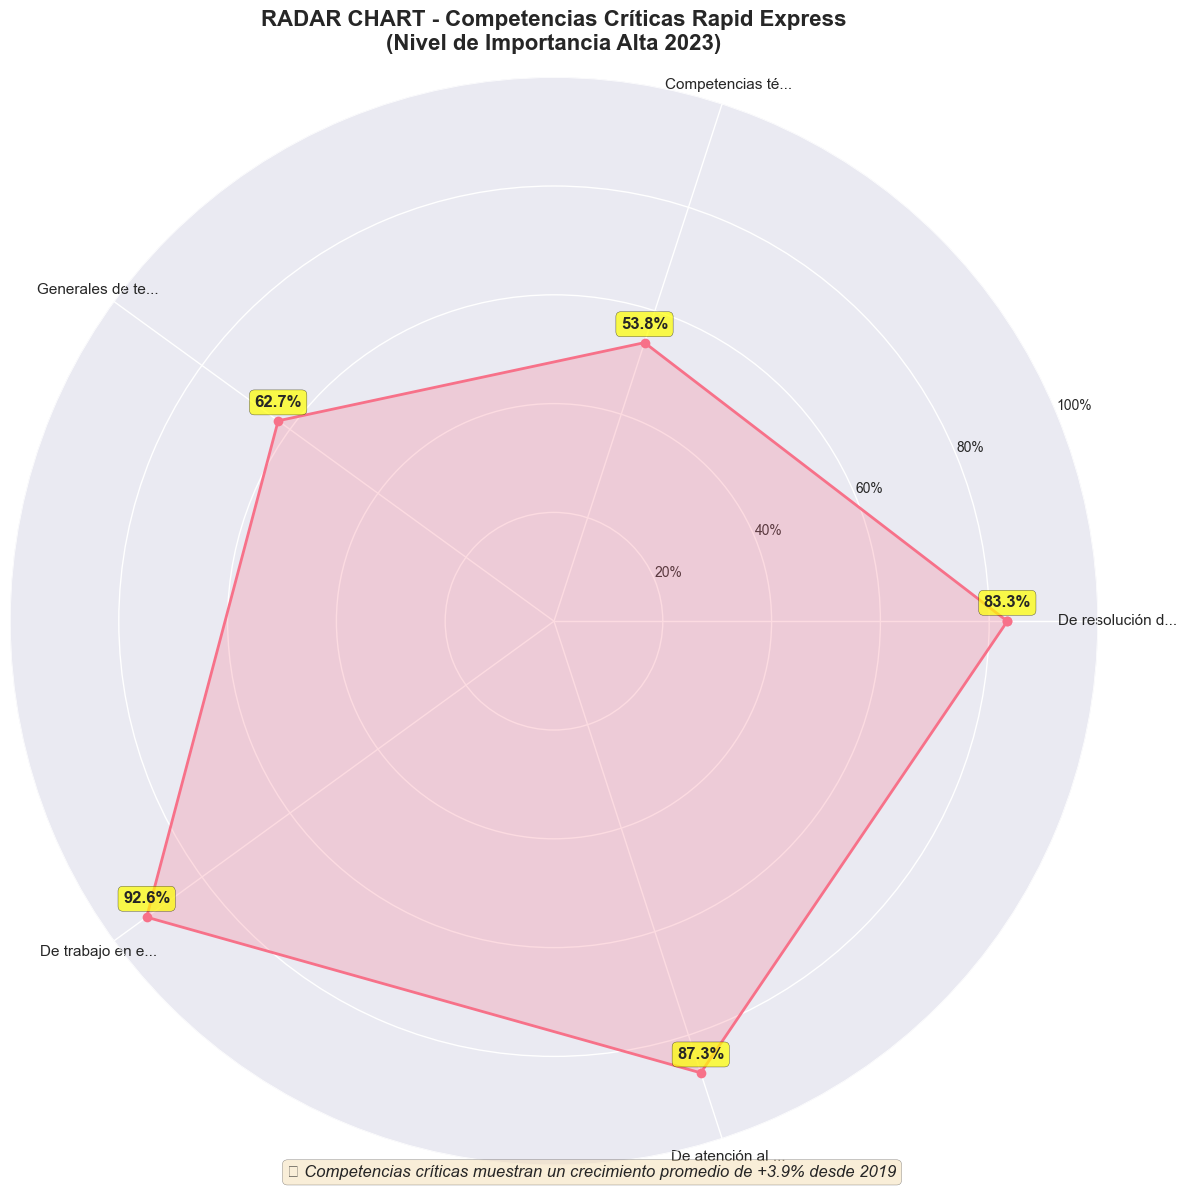

✅ Radar chart de competencias críticas generado


In [52]:
# =============================================================================
# VISUALIZACIÓN 3 - RADAR CHART DE COMPETENCIAS CRÍTICAS
# =============================================================================

print("\n🎯 Generando Radar Chart de Competencias Críticas...")

# Filtrar solo competencias críticas usando datos limpios
df_radar = df_priorizacion_clean[df_priorizacion_clean['Competencia'].isin(COMPETENCIAS_CRITICAS)].copy()

if len(df_radar) > 0:
    # Preparar datos
    categorias = df_radar['Competencia'].tolist()
    categorias_cortas = [cat[:15] + '...' if len(cat) > 15 else cat for cat in categorias]
    valores = df_radar['Importancia_Alta'].tolist()
    
    # Completar el círculo
    categorias_radar = categorias_cortas + [categorias_cortas[0]]
    valores_radar = valores + [valores[0]]
    
    # Calcular ángulos
    angulos = [n / float(len(categorias)) * 2 * np.pi for n in range(len(categorias))]
    angulos += [angulos[0]]
    
    # Crear radar chart
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
    
    # Dibujar el gráfico
    ax.plot(angulos, valores_radar, 'o-', linewidth=2, label='Importancia Alta 2023')
    ax.fill(angulos, valores_radar, alpha=0.25)
    
    # Configurar ejes
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(categorias_cortas, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=10)
    ax.grid(True)
    
    # Añadir valores
    for angulo, valor, categoria in zip(angulos[:-1], valores, categorias_cortas):
        ax.annotate(f'{valor:.1f}%', 
                   (angulo, valor),
                   textcoords='offset points', 
                   xytext=(0,10), 
                   ha='center', 
                   fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))
    
    plt.title('RADAR CHART - Competencias Críticas Rapid Express\n(Nivel de Importancia Alta 2023)', 
              size=16, fontweight='bold', pad=20)
    
    # Añadir información adicional
    crecimiento_promedio_criticas = df_matriz_clean[df_matriz_clean['Competencia'].isin(COMPETENCIAS_CRITICAS)]['Crecimiento'].mean()
    plt.figtext(0.5, 0.01, 
                f'💡 Competencias críticas muestran un crecimiento promedio de {crecimiento_promedio_criticas:+.1f}% desde 2019',
                ha='center', fontsize=12, style='italic',
                bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No hay datos suficientes para generar el radar chart de competencias críticas")

print("✅ Radar chart de competencias críticas generado")


📊 Generando Diagrama de Barras Horizontales Prioritarias...


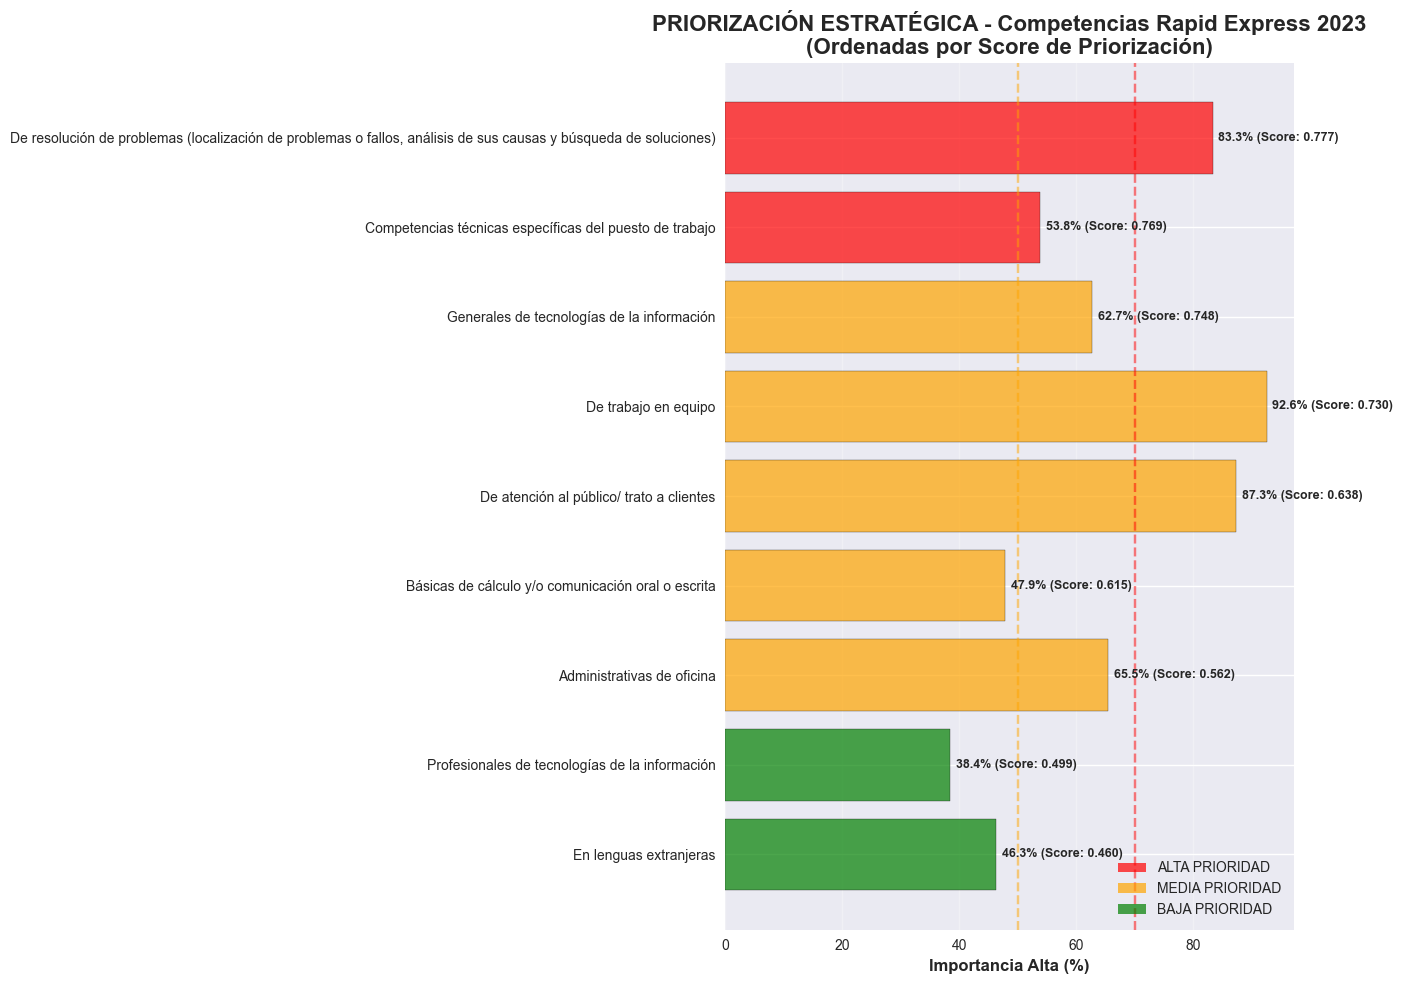

✅ Diagrama de barras horizontales generado correctamente


In [53]:
# =============================================================================
# VISUALIZACIÓN 4 - DIAGRAMA DE BARRAS HORIZONTALES PRIORITARIAS
# =============================================================================

print("\n📊 Generando Diagrama de Barras Horizontales Prioritarias...")

# Usar datos limpios
df_barras = df_priorizacion_clean.sort_values('Score_Final', ascending=True)

# CORRECCIÓN: Manejar seguridad en la asignación de colores
colores = {'ALTA': 'red', 'MEDIA': 'orange', 'BAJA': 'green'}
colores_barras = [colores.get(str(p), 'gray') for p in df_barras['Prioridad']]  # Usar .get() para evitar KeyError

# Configurar el gráfico
fig, ax = plt.subplots(figsize=(14, 10))

# Crear barras horizontales
barras = ax.barh(df_barras['Competencia'], df_barras['Importancia_Alta'], 
                 color=colores_barras, alpha=0.7, edgecolor='black')

# Añadir valores en las barras
for i, (barra, valor, score, prioridad) in enumerate(zip(barras, 
                                                        df_barras['Importancia_Alta'], 
                                                        df_barras['Score_Final'],
                                                        df_barras['Prioridad'])):
    ax.text(barra.get_width() + 1, barra.get_y() + barra.get_height()/2,
            f'{valor:.1f}% (Score: {score:.3f})', 
            ha='left', va='center', fontweight='bold', fontsize=9)

# Configurar ejes y título
ax.set_xlabel('Importancia Alta (%)', fontsize=12, fontweight='bold')
ax.set_title('PRIORIZACIÓN ESTRATÉGICA - Competencias Rapid Express 2023\n(Ordenadas por Score de Priorización)', 
             fontsize=16, fontweight='bold')

# Añadir líneas de referencia verticales
ax.axvline(x=70, color='red', linestyle='--', alpha=0.5, label='Umbral Alta Importancia (70%)')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='Umbral Media Importancia (50%)')

# Leyenda personalizada
from matplotlib.patches import Patch
leyenda_elementos = [
    Patch(facecolor='red', label='ALTA PRIORIDAD', alpha=0.7),
    Patch(facecolor='orange', label='MEDIA PRIORIDAD', alpha=0.7),
    Patch(facecolor='green', label='BAJA PRIORIDAD', alpha=0.7)
]
ax.legend(handles=leyenda_elementos, loc='lower right')

# Cuadrícula
ax.grid(True, axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("✅ Diagrama de barras horizontales generado correctamente")


📈 Generando Dashboard Resumen Ejecutivo...


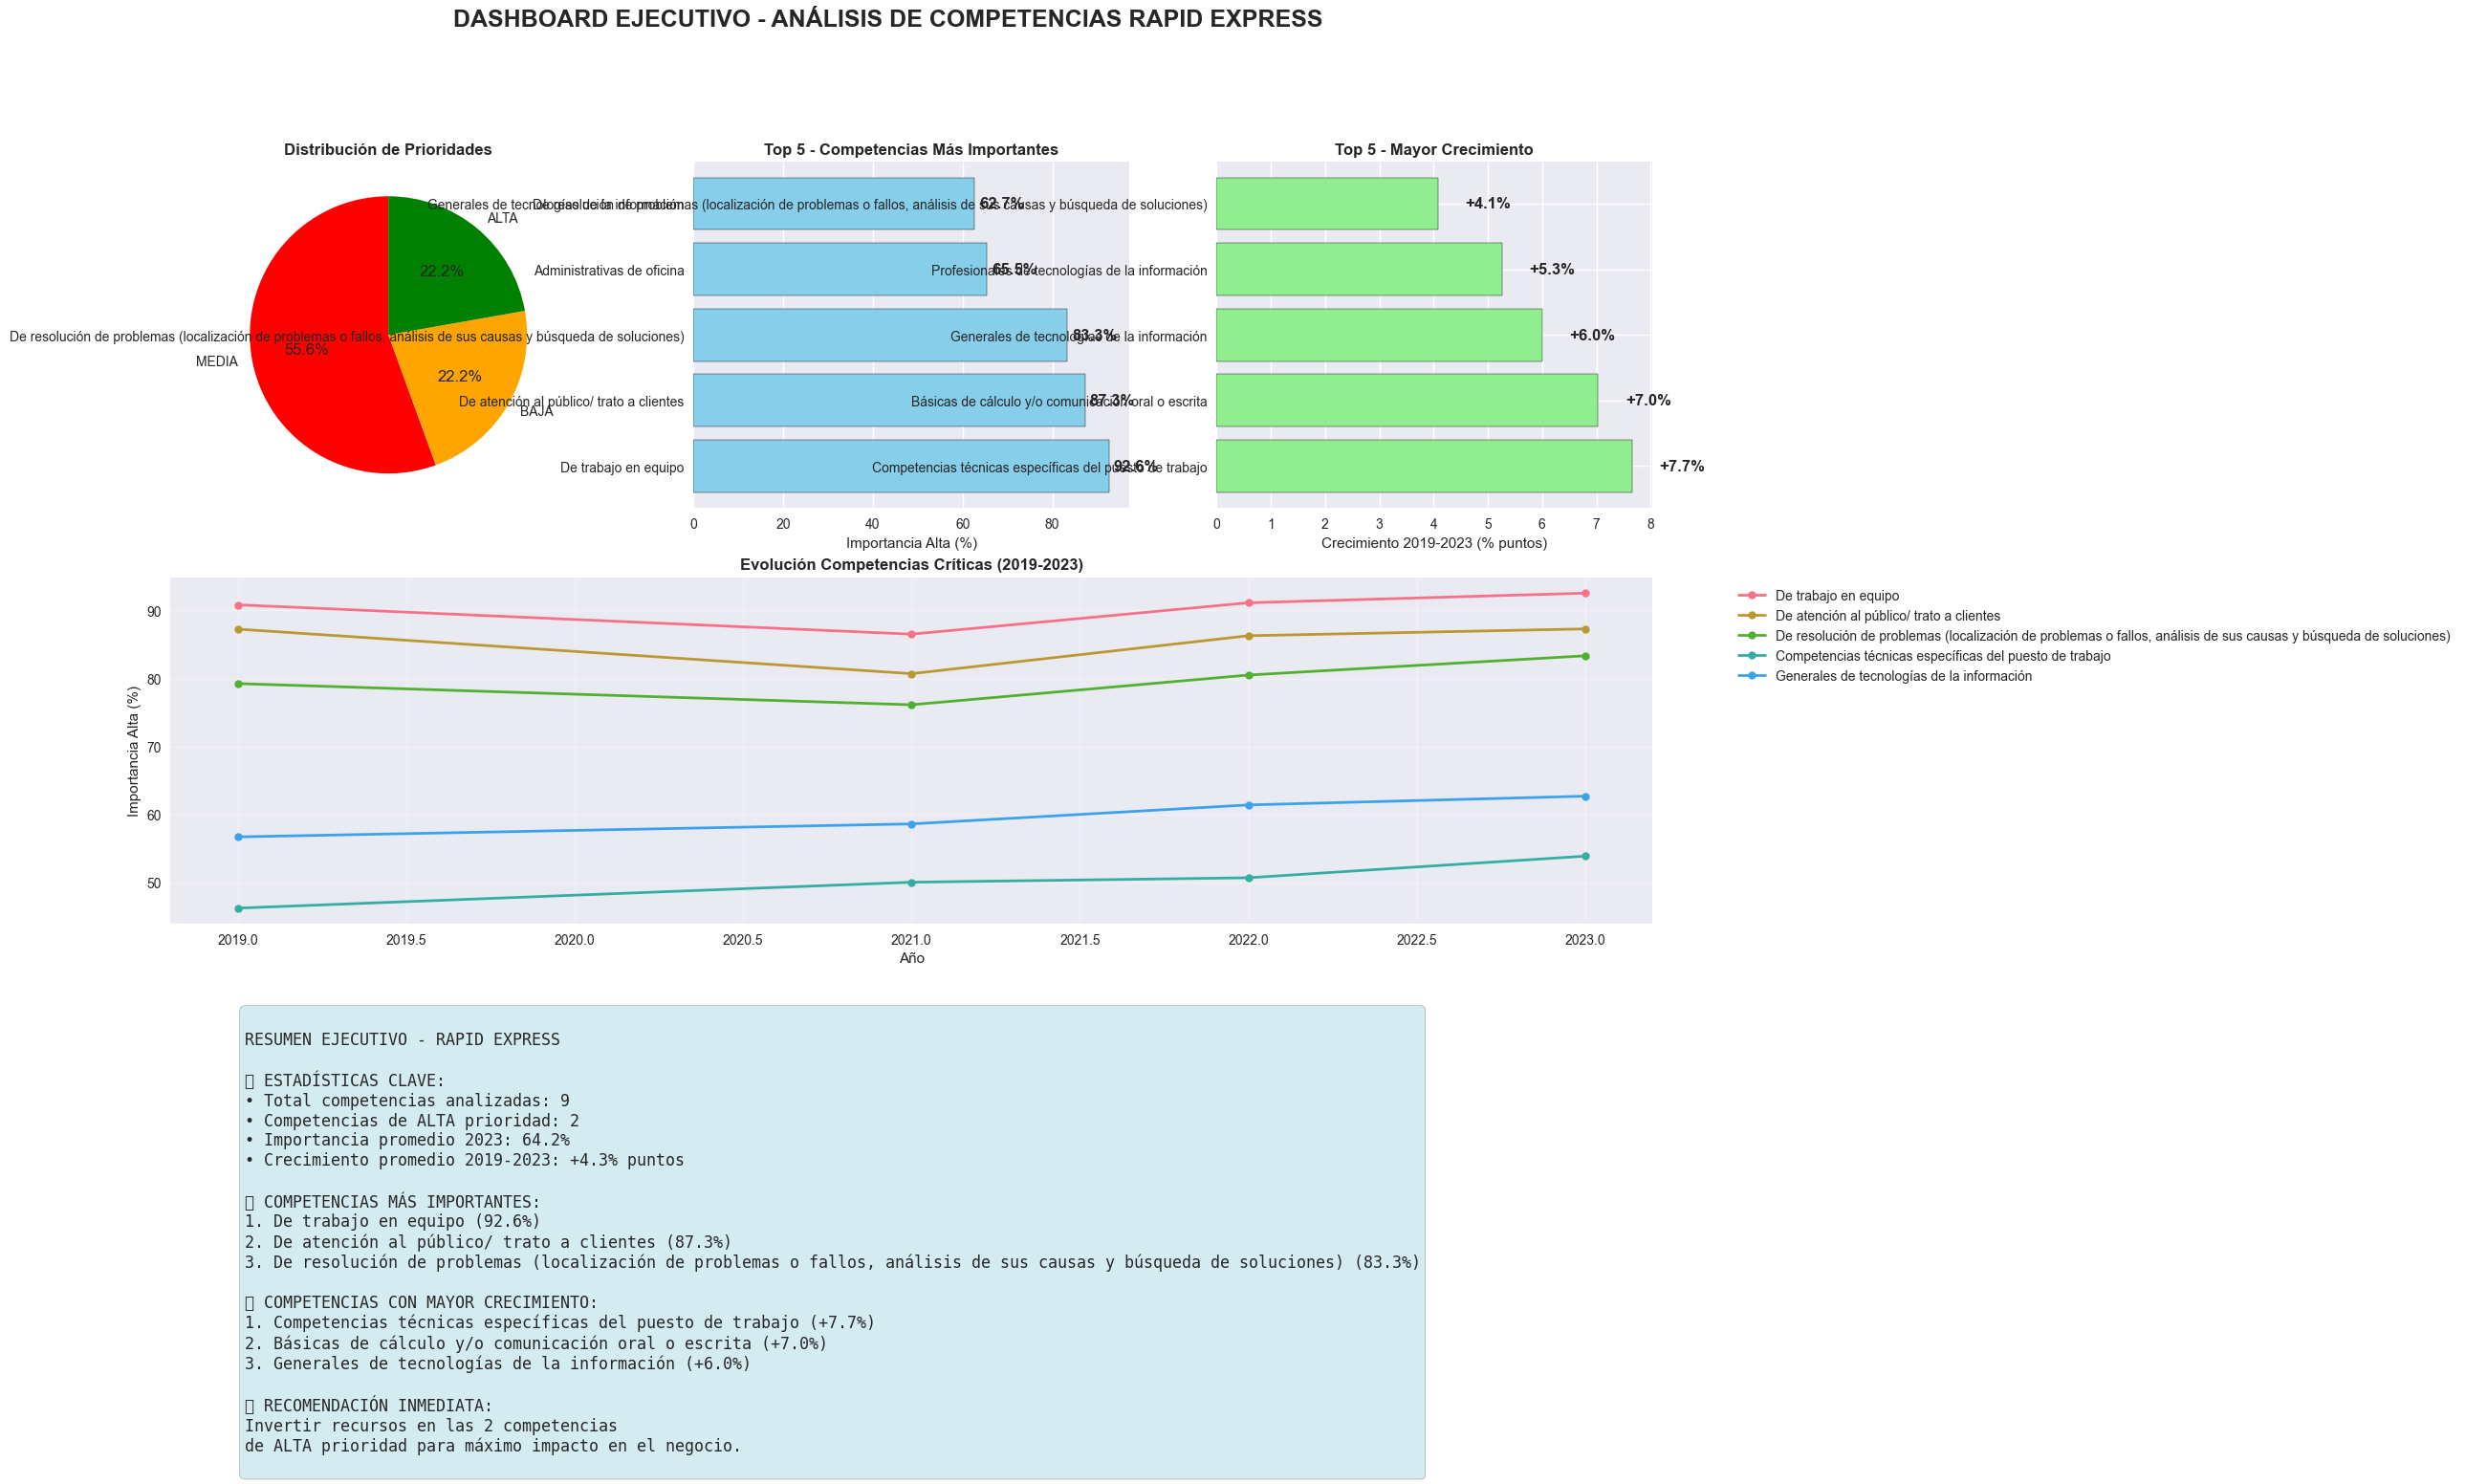

✅ Dashboard ejecutivo generado


In [54]:
# =============================================================================
# VISUALIZACIÓN 5 - DASHBOARD RESUMEN EJECUTIVO
# =============================================================================

print("\n📈 Generando Dashboard Resumen Ejecutivo...")

# Crear dashboard con múltiples subgráficos
fig = plt.figure(figsize=(20, 16))
fig.suptitle('DASHBOARD EJECUTIVO - ANÁLISIS DE COMPETENCIAS RAPID EXPRESS', 
             fontsize=18, fontweight='bold', y=0.98)

# Definir el layout del dashboard
gs = fig.add_gridspec(3, 3)

# 1. Gráfico de torta - Distribución de prioridades
ax1 = fig.add_subplot(gs[0, 0])
distribucion_prioridades = df_priorizacion_clean['Prioridad'].value_counts()
colores_torta = ['red', 'orange', 'green']
ax1.pie(distribucion_prioridades.values, labels=distribucion_prioridades.index, 
        autopct='%1.1f%%', colors=colores_torta, startangle=90)
ax1.set_title('Distribución de Prioridades', fontweight='bold')

# 2. Barras - Top 5 competencias más importantes
ax2 = fig.add_subplot(gs[0, 1])
top_5_importancia = df_priorizacion_clean.nlargest(5, 'Importancia_Alta')
ax2.barh(top_5_importancia['Competencia'], top_5_importancia['Importancia_Alta'],
         color='skyblue', edgecolor='black')
ax2.set_xlabel('Importancia Alta (%)')
ax2.set_title('Top 5 - Competencias Más Importantes', fontweight='bold')
for i, v in enumerate(top_5_importancia['Importancia_Alta']):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

# 3. Barras - Top 5 mayor crecimiento
ax3 = fig.add_subplot(gs[0, 2])
top_5_crecimiento = df_matriz_clean.nlargest(5, 'Crecimiento')
ax3.barh(top_5_crecimiento['Competencia'], top_5_crecimiento['Crecimiento'],
         color='lightgreen', edgecolor='black')
ax3.set_xlabel('Crecimiento 2019-2023 (% puntos)')
ax3.set_title('Top 5 - Mayor Crecimiento', fontweight='bold')
for i, v in enumerate(top_5_crecimiento['Crecimiento']):
    ax3.text(v + 0.5, i, f'{v:+.1f}%', va='center', fontweight='bold')

# 4. Evolución temporal de competencias críticas
ax4 = fig.add_subplot(gs[1, :])
for competencia in COMPETENCIAS_CRITICAS:
    datos_competencia = df_completo[df_completo['Competencia'] == competencia]
    if len(datos_competencia) > 0:
        ax4.plot(datos_competencia['Año'], datos_competencia['Importancia_Alta'],
                marker='o', linewidth=2, markersize=6, label=competencia)
ax4.set_xlabel('Año')
ax4.set_ylabel('Importancia Alta (%)')
ax4.set_title('Evolución Competencias Críticas (2019-2023)', fontweight='bold')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

# 5. Resumen numérico (texto)
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')  # Ocultar ejes para el texto

# Estadísticas clave
estadisticas_clave = f"""
RESUMEN EJECUTIVO - RAPID EXPRESS

📊 ESTADÍSTICAS CLAVE:
• Total competencias analizadas: {len(df_priorizacion_clean)}
• Competencias de ALTA prioridad: {len(df_priorizacion_clean[df_priorizacion_clean['Prioridad'] == 'ALTA'])}
• Importancia promedio 2023: {df_priorizacion_clean['Importancia_Alta'].mean():.1f}%
• Crecimiento promedio 2019-2023: {df_matriz_clean['Crecimiento'].mean():+.1f}% puntos

🎯 COMPETENCIAS MÁS IMPORTANTES:
1. {top_5_importancia.iloc[0]['Competencia']} ({top_5_importancia.iloc[0]['Importancia_Alta']:.1f}%)
2. {top_5_importancia.iloc[1]['Competencia']} ({top_5_importancia.iloc[1]['Importancia_Alta']:.1f}%)
3. {top_5_importancia.iloc[2]['Competencia']} ({top_5_importancia.iloc[2]['Importancia_Alta']:.1f}%)

🚀 COMPETENCIAS CON MAYOR CRECIMIENTO:
1. {top_5_crecimiento.iloc[0]['Competencia']} ({top_5_crecimiento.iloc[0]['Crecimiento']:+.1f}%)
2. {top_5_crecimiento.iloc[1]['Competencia']} ({top_5_crecimiento.iloc[1]['Crecimiento']:+.1f}%)
3. {top_5_crecimiento.iloc[2]['Competencia']} ({top_5_crecimiento.iloc[2]['Crecimiento']:+.1f}%)

💡 RECOMENDACIÓN INMEDIATA:
Invertir recursos en las {len(df_priorizacion_clean[df_priorizacion_clean['Prioridad'] == 'ALTA'])} competencias 
de ALTA prioridad para máximo impacto en el negocio.
"""

ax5.text(0.05, 0.95, estadisticas_clave, transform=ax5.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle="round", facecolor='lightblue', alpha=0.5),
         fontfamily='monospace')

plt.tight_layout()
plt.show()

print("✅ Dashboard ejecutivo generado")


🛣️  Generando Roadmap de Implementación...
📋 Roadmap incluye: 5 competencias
   • Corto plazo (ALTA): 2 competencias
   • Medio plazo (MEDIA): 3 competencias


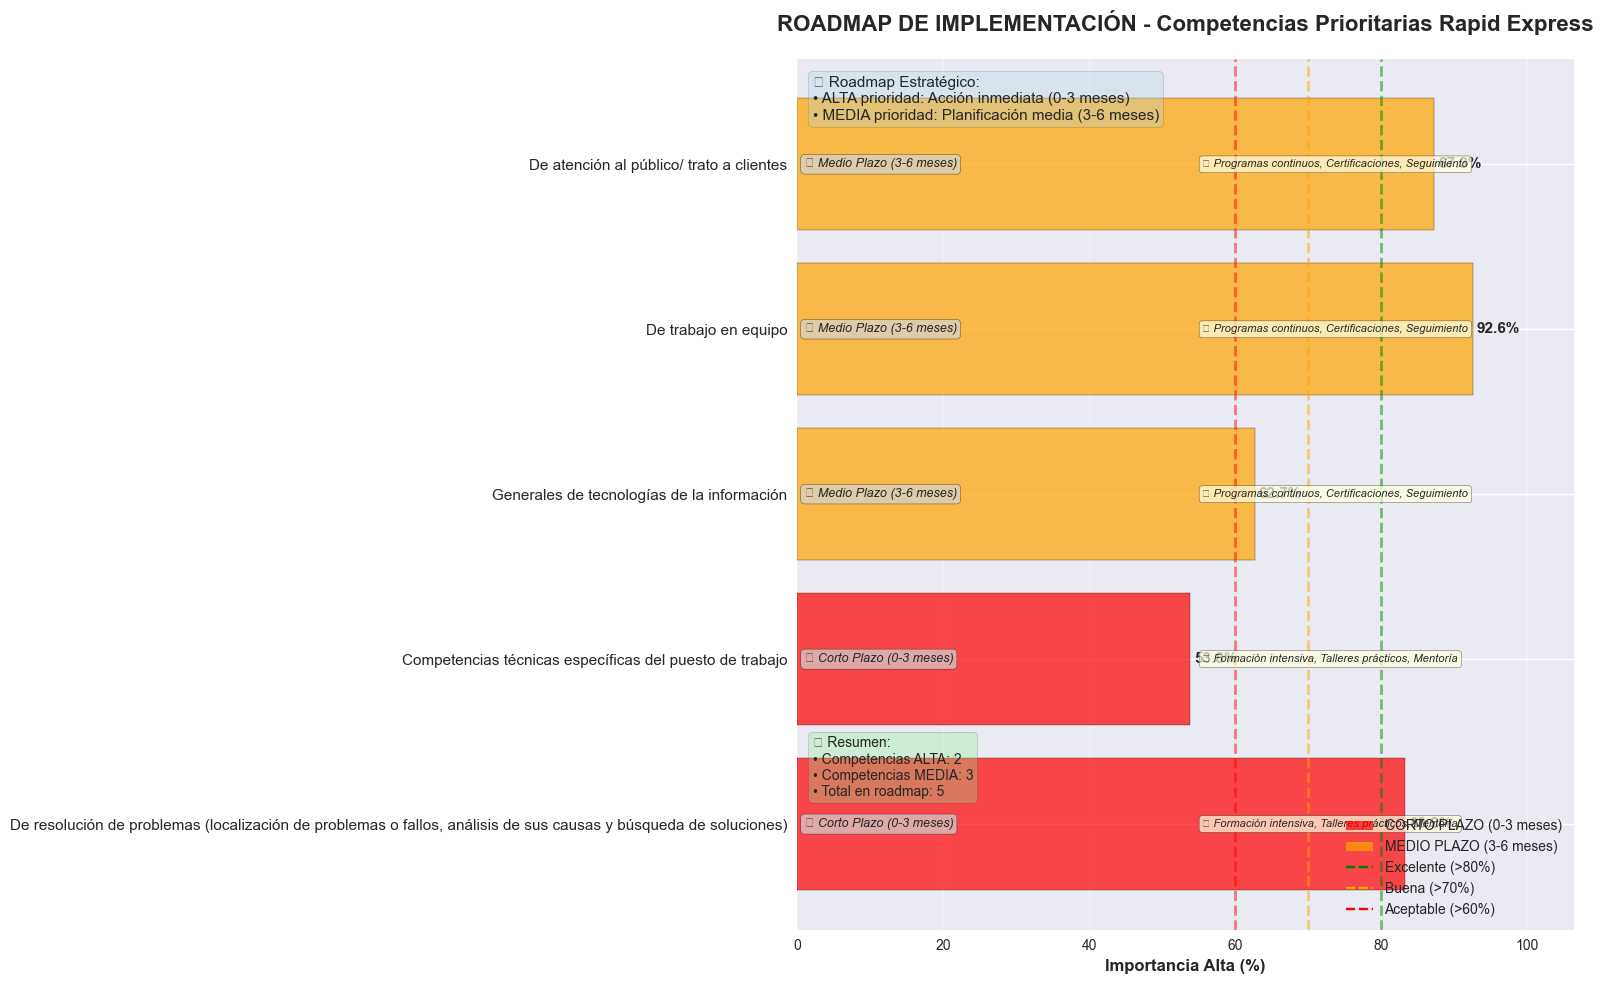


📋 DETALLE DEL ROADMAP:

1. De resolución de problemas (localización de problemas o fallos, análisis de sus causas y búsqueda de soluciones)
   • Importancia: 83.3%
   • Timeline: Corto Plazo (0-3 meses)
   • Acciones: Formación intensiva, Talleres prácticos, Mentoría

2. Competencias técnicas específicas del puesto de trabajo
   • Importancia: 53.8%
   • Timeline: Corto Plazo (0-3 meses)
   • Acciones: Formación intensiva, Talleres prácticos, Mentoría

3. Generales de tecnologías de la información
   • Importancia: 62.7%
   • Timeline: Medio Plazo (3-6 meses)
   • Acciones: Programas continuos, Certificaciones, Seguimiento

4. De trabajo en equipo
   • Importancia: 92.6%
   • Timeline: Medio Plazo (3-6 meses)
   • Acciones: Programas continuos, Certificaciones, Seguimiento

5. De atención al público/ trato a clientes
   • Importancia: 87.3%
   • Timeline: Medio Plazo (3-6 meses)
   • Acciones: Programas continuos, Certificaciones, Seguimiento
✅ Roadmap de implementación generado corre

In [55]:
# =============================================================================
# VISUALIZACIÓN 6 - ROADMAP DE IMPLEMENTACIÓN (COMPLETAMENTE CORREGIDA)
# =============================================================================

print("\n🛣️  Generando Roadmap de Implementación...")

# Crear roadmap basado en prioridades
roadmap_data = []

# Para ALTA prioridad - todas las competencias
alta_prioridad_df = df_priorizacion_clean[df_priorizacion_clean['Prioridad'] == 'ALTA']
for _, row in alta_prioridad_df.iterrows():
    roadmap_data.append({
        'Competencia': row['Competencia'],
        'Importancia': row['Importancia_Alta'],
        'Timeline': 'Corto Plazo (0-3 meses)',
        'Acciones': ['Formación intensiva', 'Talleres prácticos', 'Mentoría'],
        'Color': 'red'
    })

# Para MEDIA prioridad - solo las primeras 3
media_prioridad_df = df_priorizacion_clean[df_priorizacion_clean['Prioridad'] == 'MEDIA']
for _, row in media_prioridad_df.head(3).iterrows():
    roadmap_data.append({
        'Competencia': row['Competencia'],
        'Importancia': row['Importancia_Alta'], 
        'Timeline': 'Medio Plazo (3-6 meses)',
        'Acciones': ['Programas continuos', 'Certificaciones', 'Seguimiento'],
        'Color': 'orange'
    })

print(f"📋 Roadmap incluye: {len(roadmap_data)} competencias")
print(f"   • Corto plazo (ALTA): {len(alta_prioridad_df)} competencias")
print(f"   • Medio plazo (MEDIA): {min(3, len(media_prioridad_df))} competencias")

# Verificar que tenemos datos
if len(roadmap_data) == 0:
    print("❌ No hay datos para el roadmap")
else:
    # Crear visualización del roadmap
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Preparar datos para el gráfico
    competencias = [item['Competencia'] for item in roadmap_data]
    importancias = [item['Importancia'] for item in roadmap_data]
    colores = [item['Color'] for item in roadmap_data]
    timelines = [item['Timeline'] for item in roadmap_data]
    
    # Crear barras horizontales
    y_pos = range(len(competencias))
    barras = ax.barh(y_pos, importancias, color=colores, alpha=0.7, edgecolor='black', height=0.8)
    
    # Añadir valores en las barras
    for i, (barra, importancia) in enumerate(zip(barras, importancias)):
        ax.text(importancia + 0.5, i, f'{importancia:.1f}%', 
                va='center', fontweight='bold', fontsize=11)
    
    # Configurar ejes
    ax.set_yticks(y_pos)
    ax.set_yticklabels(competencias, fontsize=11)
    ax.set_xlabel('Importancia Alta (%)', fontweight='bold', fontsize=12)
    ax.set_title('ROADMAP DE IMPLEMENTACIÓN - Competencias Prioritarias Rapid Express', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Añadir líneas de referencia
    ax.axvline(x=80, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Excelente (>80%)')
    ax.axvline(x=70, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='Buena (>70%)')
    ax.axvline(x=60, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Aceptable (>60%)')
    
    # Configurar límites del eje X
    max_importancia = max(importancias) if importancias else 100
    ax.set_xlim(0, max(100, max_importancia * 1.15))
    
    # Leyenda personalizada
    from matplotlib.patches import Patch
    leyenda_elementos = [
        Patch(facecolor='red', label='CORTO PLAZO (0-3 meses)', alpha=0.7),
        Patch(facecolor='orange', label='MEDIO PLAZO (3-6 meses)', alpha=0.7),
        plt.Line2D([0], [0], color='green', linestyle='--', label='Excelente (>80%)'),
        plt.Line2D([0], [0], color='orange', linestyle='--', label='Buena (>70%)'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Aceptable (>60%)')
    ]
    ax.legend(handles=leyenda_elementos, loc='lower right', fontsize=10)
    
    # Cuadrícula
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    
    # Añadir información de timeline como anotaciones
    for i, item in enumerate(roadmap_data):
        # Acortar el nombre de la competencia si es muy largo
        competencia_corta = item['Competencia'][:35] + '...' if len(item['Competencia']) > 35 else item['Competencia']
        
        # Añadir timeline como texto en el gráfico
        ax.text(1, i, f"⏰ {item['Timeline']}", 
                va='center', fontsize=9, style='italic',
                bbox=dict(boxstyle="round", facecolor='lightgray', alpha=0.7))
        
        # Añadir acciones como tooltip (se verá al hacer hover, pero también como texto)
        acciones_texto = ', '.join(item['Acciones'])
        ax.text(max_importancia * 0.6, i, f"📋 {acciones_texto}", 
                va='center', fontsize=8, style='italic',
                bbox=dict(boxstyle="round", facecolor='lightyellow', alpha=0.7))
    
    # Añadir anotación explicativa general
    ax.text(0.02, 0.98, '💡 Roadmap Estratégico:\n• ALTA prioridad: Acción inmediata (0-3 meses)\n• MEDIA prioridad: Planificación media (3-6 meses)', 
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor='lightblue', alpha=0.3))
    
    # Añadir estadísticas resumen
    total_alta = len(alta_prioridad_df)
    total_media = min(3, len(media_prioridad_df))
    ax.text(0.02, 0.15, f'📊 Resumen:\n• Competencias ALTA: {total_alta}\n• Competencias MEDIA: {total_media}\n• Total en roadmap: {len(roadmap_data)}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
            bbox=dict(boxstyle="round", facecolor='lightgreen', alpha=0.3))
    
    plt.tight_layout()
    
    # Mostrar el gráfico
    plt.show()
    
    # También mostrar la información en consola
    print("\n📋 DETALLE DEL ROADMAP:")
    print("="*80)
    for i, item in enumerate(roadmap_data, 1):
        print(f"\n{i}. {item['Competencia']}")
        print(f"   • Importancia: {item['Importancia']:.1f}%")
        print(f"   • Timeline: {item['Timeline']}")
        print(f"   • Acciones: {', '.join(item['Acciones'])}")

print("✅ Roadmap de implementación generado correctamente")

In [56]:
# =============================================================================
# EXPORTACIÓN DE RESULTADOS - VERSIÓN COMPLETA CORREGIDA
# =============================================================================

print("\n💾 Exportando resultados...")

try:
    # Exportar dataset completo
    df_completo.to_csv(f"{RUTA_SALIDA}\\competencias_analisis_completo.csv", index=False, encoding='utf-8-sig')
    
    # Exportar priorización
    df_priorizacion_clean.to_csv(f"{RUTA_SALIDA}\\competencias_priorizacion_estrategica.csv", index=False, encoding='utf-8-sig')
    
    # Exportar tendencias
    tendencias.to_csv(f"{RUTA_SALIDA}\\competencias_tendencias.csv", index=False, encoding='utf-8-sig')
    
    # Exportar matriz de priorización
    df_matriz_clean.to_csv(f"{RUTA_SALIDA}\\competencias_matriz_priorizacion.csv", index=False, encoding='utf-8-sig')
    
    # Exportar resumen ejecutivo CORREGIDO
    with open(f"{RUTA_SALIDA}\\resumen_ejecutivo_competencias.txt", 'w', encoding='utf-8') as f:
        f.write("RESUMEN EJECUTIVO - ANÁLISIS DE COMPETENCIAS RAPID EXPRESS\n")
        f.write("="*60 + "\n\n")
        f.write(f"Fecha de generación: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write("COMPETENCIAS DE ALTA PRIORIDAD:\n")
        alta_prioridad = df_priorizacion_clean[df_priorizacion_clean['Prioridad'] == 'ALTA']
        if len(alta_prioridad) > 0:
            for _, row in alta_prioridad.iterrows():
                f.write(f"• {row['Competencia']} (Importancia: {row['Importancia_Alta']:.1f}%, Score: {row['Score_Final']:.3f})\n")
        else:
            f.write("• No se identificaron competencias de alta prioridad con los criterios actuales\n")
        
        f.write(f"\nESTADÍSTICAS:\n")
        f.write(f"• Total competencias analizadas: {len(df_priorizacion_clean)}\n")
        f.write(f"• Competencias alta prioridad: {len(alta_prioridad)}\n")
        f.write(f"• Competencias media prioridad: {len(df_priorizacion_clean[df_priorizacion_clean['Prioridad'] == 'MEDIA'])}\n")
        f.write(f"• Competencias baja prioridad: {len(df_priorizacion_clean[df_priorizacion_clean['Prioridad'] == 'BAJA'])}\n")
        f.write(f"• Importancia promedio 2023: {df_priorizacion_clean['Importancia_Alta'].mean():.1f}%\n")
        f.write(f"• Crecimiento promedio 2019-2023: {df_matriz_clean['Crecimiento'].mean():+.1f}% puntos\n")
        f.write(f"• Score promedio: {df_priorizacion_clean['Score_Final'].mean():.3f}\n")
        
        # Añadir top 3 competencias más importantes
        top_importancia = df_priorizacion_clean.nlargest(3, 'Importancia_Alta')
        f.write(f"\n🎯 TOP 3 COMPETENCIAS MÁS IMPORTANTES (2023):\n")
        for i, (_, row) in enumerate(top_importancia.iterrows(), 1):
            f.write(f"{i}. {row['Competencia']} ({row['Importancia_Alta']:.1f}%)\n")
        
        # Añadir top 3 mayor crecimiento
        top_crecimiento = df_matriz_clean.nlargest(3, 'Crecimiento')
        f.write(f"\n🚀 TOP 3 MAYOR CRECIMIENTO (2019-2023):\n")
        for i, (_, row) in enumerate(top_crecimiento.iterrows(), 1):
            f.write(f"{i}. {row['Competencia']} ({row['Crecimiento']:+.1f}%)\n")
        
        f.write(f"\n💡 RECOMENDACIÓN ESTRATÉGICA:\n")
        if len(alta_prioridad) > 0:
            f.write(f"Invertir recursos prioritariamente en las {len(alta_prioridad)} competencias de ALTA prioridad.\n")
            f.write("Estas competencias combinan alta importancia actual con crecimiento significativo\n")
            f.write("y relevancia crítica para el sector logística y transporte.\n")
        else:
            f.write("Enfoque en mantener las competencias actuales y desarrollar aquellas\n")
            f.write("con mayor potencial de crecimiento y alineación estratégica.\n")
    
    print("✅ Resultados exportados correctamente:")
    print(f"   • competencias_analisis_completo.csv")
    print(f"   • competencias_priorizacion_estrategica.csv")
    print(f"   • competencias_tendencias.csv")
    print(f"   • competencias_matriz_priorizacion.csv")
    print(f"   • resumen_ejecutivo_competencias.txt")

except Exception as e:
    print(f"⚠️  Error en exportación: {e}")

print("\n" + "="*80)
print("🎉 ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*80)
print(f"📅 Finalizado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


💾 Exportando resultados...
✅ Resultados exportados correctamente:
   • competencias_analisis_completo.csv
   • competencias_priorizacion_estrategica.csv
   • competencias_tendencias.csv
   • competencias_matriz_priorizacion.csv
   • resumen_ejecutivo_competencias.txt

🎉 ANÁLISIS COMPLETADO EXITOSAMENTE
📅 Finalizado: 2025-10-15 08:43:44
